# Synthesizing ID columns in SDV to match your real data ID column patterns

In this guide, we will explore how you can synthesize ID columns to match the patterns in your real data. We will use a multi-table dataset to demonstrate the different types of ID columns and how SDV handles each case.

**What will we cover in this guide?**

* What are the different types of ID columns?  
* What common patterns exist for ID columns?  
* What is a regex (regular expression), and how can it be used to define ID patterns?  
* What is the default behavior of SDV when modeling ID columns?  
* How can you control SDV’s ID generation so that the generated IDs match your real data, such as in format or pattern?

## Types of ID columns

ID columns can exist across several tables. They are extremely meaningful to connect entities across tables.

* Sometimes ID columns are **primary keys**, a unique identifier for the entities in the table.    
* ID columns can also be **foreign keys**, which must refer to the primary key in another table. For this guide, we will refer to primary and foreign keys, as **Keys**.   
* ID columns can also be **non-Keys**. This is an ID column which is not a primary key (it may repeat) nor is it a foreign key (it does not refer to a primary key in the provided dataset).  

## Patterns we see in ID columns

ID columns may have patterns that you would like to emulate.

### A well defined pattern that has a meaning

These patterns usually occur when these IDs are strings, which may be indicative of certain characteristics of the entity. For example, a bank account ID starting with UB-AUS-CR-98938 and the first 7 letters may indicate the following:

* UB implies that it is “unified banking” product account   
* AUS implies that this account is in Australia and  
* CR implies that this is a credit account.

You may want to create IDs which follow a similar, meaningful pattern, across tables.

### Fixed length randomly generated pattern

In other cases, there may not be a pattern like this, but it could be a randomly generated pattern with a *fixed length*. For example, you may have in your real data employee IDs which are exactly 9 characters long, such as `139C8A021`. The characters are random and have no meaning. And you may wish to emulate that in your synthetic data.

In order to represent these patterns in ID columns, we can use a regular expression.  

## What is a regular expression (regex)?

A regular expression, known as regex, is a sequence of characters used to specify the values allowed in a text. For example, you could use a regex to specify:

* A text must contain only 4 digits.  
* A text must contain dashes.  
* A text must start or end with `UB`.  
* A text must contain only letters and numbers.

By specifying a regex to SDV, we can indicate the pattern should be used to generate new ID values.   
For the example, in the previous section, the regex expression for the bank account IDs would be `([A-Z]{2})-([A-Z]{3})-([A-Z]{2})-(\d+)`. Let’s break down this regex pattern.

* `([A-Z]{2})`: specifies exactly 2 uppercase letters from A to Z (e.g. “UB” product).  
* `-`: matches the hyphen.   
* `([A-Z]{3})`: specifies exactly 3 uppercase letters from A to Z (e.g. “AUS” country).  
* `([A-Z]{2})`: specifies exactly 2 uppercase letters from A to Z (e.g. “CR” credit account)  
* `(\d+)`: means any sequence of digits

Now, let’s install SDV and explore a multi-table dataset to understand the different types of ID columns.

# 0. Installation

Install SDV Community.

In [ ]:
%pip install "sdv>=1.29.0" -U -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.8/197.8 kB 3.5 MB/s eta 0:00:00


# 1\. Loading the dataset

We will load the `multi_table_ID_demo_dataset` dataset. This is a multi-table dataset with four tables that has different ID configurations.

In [ ]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='multi_table',
    dataset_name='multi_table_ID_demo_dataset'
)

Let's look at a few rows from each table.

In [ ]:
real_data['customers'].head()

,customer_id,name,age,email
0,54560,Linda Smith,79,linda.smith@outlook.com
1,35292,John Williams,44,john.williams_583@yahoo.com
2,48244,James Jones,79,james.jones@yahoo.com
3,70415,Jennifer Smith,82,jennifer.smith@yahoo.com
4,14152,Robert Smith,69,robert.smith_805@yahoo.com


In [ ]:
real_data['accounts'].head()

,account_id,account_type,status,balance,statement_id,customer_id
0,773268,savings,active,7739.15,STMT-2070-D,32272
1,823687,savings,closed,3949.25,STMT-3939-C,5277
2,537643,savings,closed,7789.15,STMT-5530-E,66804
3,714777,checking,active,1846.29,STMT-9595-E,5277
4,441378,savings,closed,4277.16,STMT-4033-B,12561


In [ ]:
real_data['transactions'].head()

,transaction_id,account_id,bank_id,vendor_id,payment_id,amount,product_id,code
0,t_cfdgdbup,244471,4056518,1rV8MBfM6z6Yb,26895,1573.29,285492,SE11
1,t_vxlmhkho,764102,1465689,8GHXe2,89921,1047.93,119554,SM37
2,t_lpxtpafr,907175,2663046,8SRosM,45951,2384.42,498262,SM37
3,t_wpatvote,665396,103355,jEPiP9ajbZ,70184,307.21,583918,SE11
4,t_nlhzlvzm,703530,9695979,rgGAtoNmLcbk,60713,129.78,240897,SM37


In [ ]:
real_data['banks'].head()

,bank_id,city,state,location_id
0,6423388,Boston,WA,E0IFD0TVB
1,6550634,Denver,CO,HSAH
2,4304572,Chicago,CA,ZPQK51FPK
3,2234489,Boston,MA,8MDD4
4,9958614,Austin,CO,JBQE7CKW


Looking at the data, we can see that there are several ID columns.

| Column | Type  | Key or non-Key | Pattern exists in real data  |
| :---- | :---: | :---: | :---: |
| `customer_id` | String | Key | No |
| `account_id` | Integer | Key | Yes |
| `statement_id` | String | non-Key | Yes |
| `transaction_id` | String | Key | Yes |
| `bank_id` | Integer | Key | No |
| `vendor_id` | String | non-Key | No |
| `payment_id` | Integer  | non-Key | Yes |
| `product_id` | Integer | non-Key | No |

## 1.1 Metadata

Let's look at our metadata and see the relationships between the tables. As we see in the visualization:

* A *customer* can have one or more associated *accounts*  
* An *account* can have one or more associated *transactions*  
* A *bank* can have one or more associated *transactions*

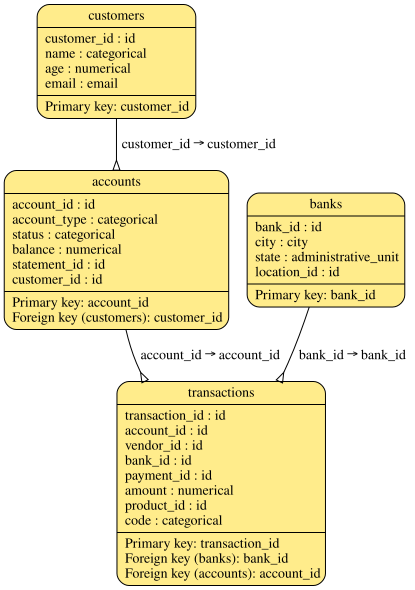

In [ ]:
metadata.visualize()

Some of our columns have patterns associated with them.   
**We can generate IDs with these specific patterns by defining regexes in the metadata.**  
**If we do not specify the patterns, SDV will still generate valid synthetic data. However, the ID values may not match your expected format.**

| ID Type | Data Type | Default Behavior (No Pattern Specified) |
| :---: | :---: | :---- |
| Key | String | Generates values prefixed with `sdv-id-` (e.g., `sdv-id-1a2b`). |
| Key | Integer | Generates new integer ID values. |
| Non-Key | String/Integer  | Re-uses ID values directly from your real data. |

Below, we define the patterns for four ID columns:

1. Transaction IDs: Must start with `t_` followed by exactly 8 lowercase letters.  
2. Account IDs: Must be a 6-digit number that does not start with zero.  
3. Statement IDs: Must follow the format `STMT-2024-XXXX-Y`, where XXXX is four digits and Y is a letter from A to E.  
4. Payment IDs: Must be a 5-digit number that does not start with zero.

In [ ]:
metadata.update_column(
    table_name='transactions',
    column_name='transaction_id',
    sdtype='id',
    regex_format='t_[a-z]{8}',
)
metadata.update_column(
    table_name='accounts',
    column_name='account_id',
    sdtype='id',
    regex_format='[1-9][0-9]{5}'
)
metadata.update_column(
    table_name='accounts',
    column_name='statement_id',
    sdtype='id',
    regex_format='STMT-2024-[0-9]{4}-[A-E]',
)
metadata.update_column(
    table_name='transactions',
    column_name='payment_id',
    sdtype='id',
    regex_format='[1-9][0-9]{4}',
)

# 2\. Generate Synthetic Data

Now, we can create an SDV **synthesizer** and generate synthetic data.  The synthesizer will learn from your real data and reference the metadata to ensure ID columns are generated as expected and preserve any applicable patterns.

In [ ]:
from sdv.multi_table import HMASynthesizer

synthesizer = HMASynthesizer(metadata, verbose=False)
synthesizer.fit(real_data)
synthetic_data = synthesizer.sample(scale=0.5)

/usr/local/lib/python3.12/dist-packages/sdv/multi_table/base.py:112: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


## 2.1 Diagnostic Report

To verify our synthetic data is correct, we will run the diagnostic report. This report will check for basic data validity and data structure issues.  
As expected, this score is 100% which means the following (for our synthetic data):

1. Primary keys are unique and not-null  
2. Each foreign key (in a child table) references a primary key that exists in the parent (i.e. referential integrity).

*Other properties, not listed, are checked in the diagnostic report.*

In [ ]:
from sdv.evaluation.multi_table import run_diagnostic

diagnostic_report = run_diagnostic(real_data=real_data, synthetic_data=synthetic_data, metadata=metadata)

Generating report ...

(1/3) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 802.05it/s]|
Data Validity Score: 100.0%

(2/3) Evaluating Data Structure: |██████████| 4/4 [00:00<00:00, 300.99it/s]|
Data Structure Score: 100.0%

(3/3) Evaluating Relationship Validity: |██████████| 3/3 [00:00<00:00, 147.93it/s]|
Relationship Validity Score: 100.0%

Overall Score (Average): 100.0%



# Keys

SDV always generates valid IDs for Keys. As seen in the diagnostic report, the entities for Keys are guaranteed to have referential integrity.

**As a user of SDV, you can control the ID pattern by specifying a regex in your metadata.**   
If you do not specify a regex, SDV will create IDs depending on the data type:

* For a key column that is a String, SDV will generate ID values which begin with `sdv-id-` (e.g. `sdv-id-1av3dc`).   
* For a key column that is an integer, SDV will generate Integer ID values.

## Keys \- String

For Keys that are strings, specifying the regex allows SDV to create entities which conform to your pattern. Because we previously defined the pattern in our metadata, the synthetic transaction IDs match our expected format:

In [ ]:
synthetic_data['transactions']['transaction_id'].head(5)

,transaction_id
0,t_aaaaaaac
1,t_aaaaaaab
2,t_aaaaaaaa
3,t_aaaaaaad
4,t_aaaaaaag


**If you do not specify a regex in your metadata, SDV will create new entities which begin with `sdv-id-`, such as `sdv-id-1av3dc`. These new entities will maintain referential integrity.**

## Keys \- Integer

For Keys which are integers, specifying the pattern allows SDV to create valid new entities. In the real `account_id` column, we saw that all Keys are 6 characters long and only contain integers. This pattern was respected in our synthetic data:

In [ ]:
synthetic_data['accounts']['account_id'].head(5)

,account_id
0,100001
1,100004
2,100010
3,100008
4,100007


**If you do not specify a regex in your metadata, SDV will create random integers, which will be valid new entities.**   
As always, the new entities will have referential integrity.   
An example of this is the `bank_id` column. In the real data, this column is an integer, but we did not provide a regex pattern for it in our metadata. As a result, SDV generates random integers as seen below:

In [ ]:
synthetic_data['banks']['bank_id'].head(5)

,bank_id
0,13868551
1,11126213
2,14797432
3,12212806
4,10553293


# non-Keys

SDV supports generating valid IDs for non-Key columns. If a non-Key column has a specified pattern, SDV will generate new IDs that conform to the pattern. If no pattern is specified, the IDs are reused from the real data.

## non-Keys \- String

For non-Key columns that are strings, specifying a regex allows SDV to create IDs which conform to your pattern. In the `statement_id` column, we can see the pattern specified in the metadata was respected.   
Specifically, all statement IDs begin with `STMT-2024-`, followed by 4 numbers and a single letter.

In [ ]:
synthetic_data['accounts']['statement_id'].head(5)

,statement_id
0,STMT-2024-0001-D
1,STMT-2024-0000-E
2,STMT-2024-0002-A
3,STMT-2024-0002-B
4,STMT-2024-0002-C


**If you do not specify a pattern for a string non-Key column, it will be treated as a categorical column.** As a result, SDV will reuse IDs from the real data in the synthetic data because it lacks the necessary information to generate new IDs.

An example of this situation can be seen in the `vendor_id` column. Since we did not provide a pattern in the metadata, SDV re-used IDs from the real data for this Key column.   
As a result, the synthetic data contains the same vendor IDs as the real data:

In [ ]:
synthetic_data['transactions']['vendor_id'].head(5)

,vendor_id
0,T63ljb77Y0
1,8qLfKz65Solwtl
2,PYpTwezbK
3,IK8are
4,4EXeiWD7OoprPhp


## non-Keys \- Integer

If a non-Key column is an integer but has a specified pattern, SDV will create valid, new IDs. This behavior can be seen in the `payment_id` column:

In [ ]:
synthetic_data['transactions']['payment_id'].head(5)

,payment_id
0,10001
1,10002
2,10003
3,10000
4,10005


However, if a non-Key column is an integer and does not have a specified pattern, SDV will reuse the IDs from the real data. This can be seen in the `product_id` column:

In [ ]:
synthetic_data['transactions']['product_id'].head(5)

,product_id
0,500997
1,346541
2,992624
3,350672
4,604272


# Keys \- Summary

A Key column can be a primary key, which uniquely identifies the entities in the associated table. A Key column can also be a foreign key, which refers to a primary key in another table and may repeat.  
When generating primary keys with SDV, the IDs will always be unique and not null. When generating foreign keys with SDV, the IDs are guaranteed to maintain referential integrity.  
If your goal is to generate IDs which match the IDs in your real data, you should specify the regex in your metadata.

| ID type  | Pattern exists in real data | You specify pattern in regex in metadata   | What it does |
| :---: | :---: | :---: | ----- |
| String  | ✔ | Yes | Creates new IDs which maintain referential integrity and match regex. |
| String  | ✔ | No | Creates new IDs (beginning with `sdv-id`) which maintain referential integrity. |
| String  | ⛌  | Not applicable  | Creates new IDs (beginning with `sdv-id`) which maintain referential integrity. |
| Integer | ✔ | Yes | Creates new IDs which maintain referential integrity and match regex. |
| Integer | ✔ | No | Creates new IDs which maintain referential integrity. |
| Integer | ⛌ | Not applicable  | Creates new IDs which maintain referential integrity. |

# Non-Keys \- Summary

Non-Keys are columns which are not a primary key (it may repeat) nor is it a foreign key.   
In this situation, you have two options. If your goal is to create new entities, you should specify a regex in your metadata. If not, you can re-use the existing entities in your real data.

| Is your goal to create new entities? | What should you do?  |
| :---: | ----- |
| Yes  | Specify regex in your metadata just as we proposed in the table above  |
| No | SDV will do this by default. It will consider your non-key column as categorical and synthesize the same ones preserving the entities' correlations with other columns in the data.  |

You can use this flowchart to determine how SDV will generate IDs for a given Key or Non-Key column:
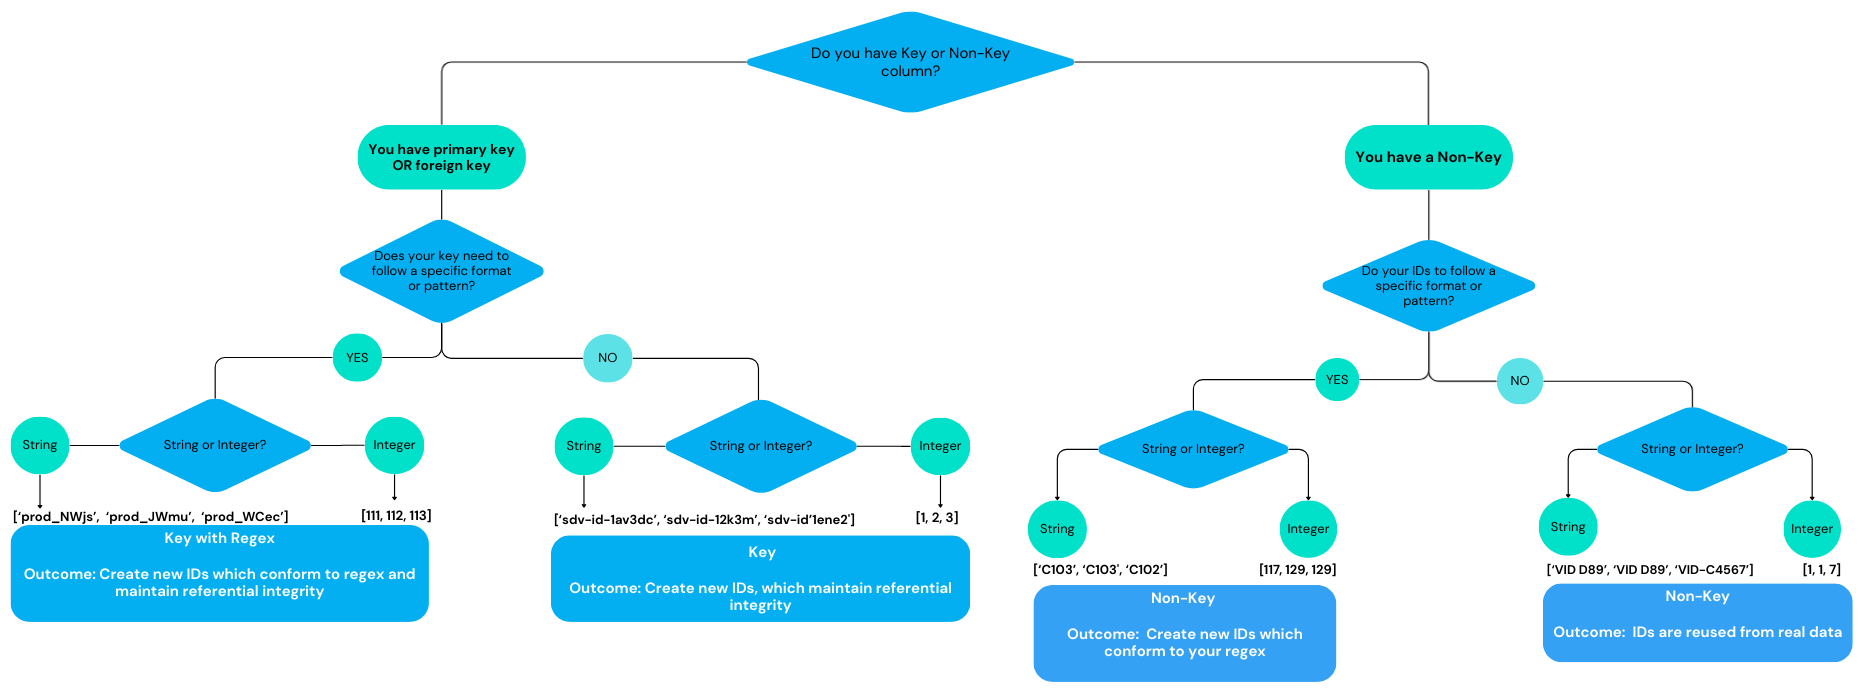